## Import Necessary Libraries

In [12]:
import os
import pandas as pd

## Assign Path Variable to Path of Data

In [13]:
base_path = r"C:\Users\Kashvi Soni\OneDrive\Documents\Data Analytics\SalesData"

## Merging 12 months of sales data in a single file:

In [14]:
one_month = pd.read_csv(fr"{base_path}\Sales_April_2019.csv") #fr = f string + raw string
one_month.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


List all files from the directory

In [15]:
files = os.listdir(base_path)
files

['Sales_April_2019.csv',
 'Sales_August_2019.csv',
 'Sales_December_2019.csv',
 'Sales_February_2019.csv',
 'Sales_January_2019.csv',
 'Sales_July_2019.csv',
 'Sales_June_2019.csv',
 'Sales_March_2019.csv',
 'Sales_May_2019.csv',
 'Sales_November_2019.csv',
 'Sales_October_2019.csv',
 'Sales_September_2019.csv']

In [17]:
all_month_data = pd.DataFrame()

for file in files:
    monthly_data = pd.read_csv(fr"{base_path}\{file}")
    all_month_data = pd.concat((all_month_data , monthly_data))

all_month_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
11681,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
11682,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
11683,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
11684,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


# Convert To CSV

In [18]:
all_month_data.to_csv(fr"{base_path}\Sales.csv" , index = False)

In [19]:
all_data = pd.read_csv(fr"{base_path}\Sales.csv")
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3,2.99,09/17/19 20:56,"840 Highland St, Los Angeles, CA 90001"
186846,259354,iPhone,1,700,09/01/19 16:00,"216 Dogwood St, San Francisco, CA 94016"
186847,259355,iPhone,1,700,09/23/19 07:39,"220 12th St, San Francisco, CA 94016"
186848,259356,34in Ultrawide Monitor,1,379.99,09/19/19 17:30,"511 Forest St, San Francisco, CA 94016"


Display all rows of NAN:

In [20]:
all_data[all_data.isna().any(axis = 1)] # Which rows have at least one missing value?

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1,NaN,NaN,NaN,NaN,NaN,NaN
356,NaN,NaN,NaN,NaN,NaN,NaN
735,NaN,NaN,NaN,NaN,NaN,NaN
1433,NaN,NaN,NaN,NaN,NaN,NaN
1553,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
185176,NaN,NaN,NaN,NaN,NaN,NaN
185438,NaN,NaN,NaN,NaN,NaN,NaN
186042,NaN,NaN,NaN,NaN,NaN,NaN
186548,NaN,NaN,NaN,NaN,NaN,NaN


Convert Order Date in Datetime

In [21]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address'],
      dtype='str')

In [22]:
all_data["Order Date"].unique()

<StringArray>
['04/19/19 08:46',              nan, '04/07/19 22:30', '04/12/19 14:38',
 '04/30/19 09:27', '04/29/19 13:03', '04/02/19 07:46', '04/12/19 10:58',
 '04/24/19 10:38', '04/08/19 14:05',
 ...
 '09/07/19 20:09', '09/14/19 19:30', '09/10/19 23:33', '09/29/19 17:24',
 '09/30/19 21:03', '09/07/19 15:49', '09/01/19 16:00', '09/23/19 07:39',
 '09/19/19 17:30', '09/30/19 00:18']
Length: 142397, dtype: str

In [23]:
all_data.dtypes

Order ID            str
Product             str
Quantity Ordered    str
Price Each          str
Order Date          str
Purchase Address    str
dtype: object

In [54]:
all_data["Order Date"] = all_data["Order Date"].str.replace('/','-')
all_date["Order Date"] = pd.to_datetime(all_data["Order Date"]) 


AttributeError: Can only use .str accessor with string values, not datetime64

In [25]:
temp = all_data.loc[all_data["Order Date"] == "Order Date"] #Give me all rows where Order Date contains the text Order Date
temp

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
519,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1149,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
1155,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2878,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
2893,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
...,...,...,...,...,...,...
185164,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
185551,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186563,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
186632,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address


In [26]:
all_data = all_data.loc[all_data["Order Date"] != "Order Date"]
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


In [27]:
all_data["Order Date"] = all_data["Order Date"].str.replace('/','-')
all_data["Order Date"] = pd.to_datetime(all_data["Order Date"])

C:\Users\Kashvi Soni\AppData\Local\Temp\ipykernel_27296\1075331697.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data["Order Date"] = pd.to_datetime(all_data["Order Date"])


In [28]:
all_data["Order Date"]

0        2019-04-19 08:46:00
1                        NaT
2        2019-04-07 22:30:00
3        2019-04-12 14:38:00
4        2019-04-12 14:38:00
                 ...        
186845   2019-09-17 20:56:00
186846   2019-09-01 16:00:00
186847   2019-09-23 07:39:00
186848   2019-09-19 17:30:00
186849   2019-09-30 00:18:00
Name: Order Date, Length: 186495, dtype: datetime64[us]

Add Month Column:

In [29]:
all_data["Month"] = all_data["Order Date"].dt.month_name()
all_data["Month"]

0             April
1               NaN
2             April
3             April
4             April
            ...    
186845    September
186846    September
186847    September
186848    September
186849    September
Name: Month, Length: 186495, dtype: str

In [30]:
all_data.columns

Index(['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Order Date',
       'Purchase Address', 'Month'],
      dtype='str')

In [31]:
all_data["Quantity Ordered"] = all_data["Quantity Ordered"].astype("float")
all_data["Price Each"] = all_data["Price Each"].astype("float")

In [32]:
all_data.dtypes

Order ID                       str
Product                        str
Quantity Ordered           float64
Price Each                 float64
Order Date          datetime64[us]
Purchase Address               str
Month                          str
dtype: object

In [33]:
all_data["TSV"] = all_data["Quantity Ordered"]*all_data["Price Each"]
all_data["TSV"]

0          23.90
1            NaN
2          99.99
3         600.00
4          11.99
           ...  
186845      8.97
186846    700.00
186847    700.00
186848    379.99
186849     11.95
Name: TSV, Length: 186495, dtype: float64

In [34]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,TSV
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",April,23.90
1,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",April,99.99
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,600.00
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,11.99


In [35]:
all_data[["Quantity Ordered" , "Price Each" , "TSV"]]

,Quantity Ordered,Price Each,TSV
0,2.0,11.95,23.90
1,NaN,NaN,NaN
2,1.0,99.99,99.99
3,1.0,600.00,600.00
4,1.0,11.99,11.99
...,...,...,...
186845,3.0,2.99,8.97
186846,1.0,700.00,700.00
186847,1.0,700.00,700.00
186848,1.0,379.99,379.99


# Best Month For Sales: December

In [36]:
all_data["Month"] = all_data["Order Date"].dt.month_name()
results = all_data.groupby("Month")["TSV"].sum().sort_values(ascending=False) #TSV = Total Sales Value

In [37]:
import matplotlib.pyplot as plt

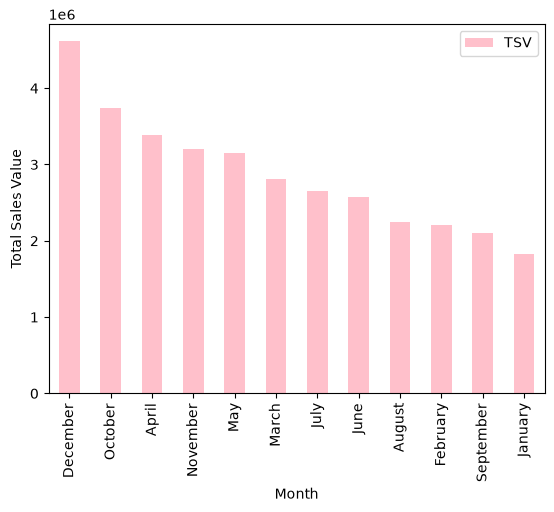

In [38]:
results.plot(
    kind='bar',
    color='pink'
)
plt.legend()
plt.ylabel("Total Sales Value")
plt.show()

- December is a festive month, the biggest thing is that December is Christmas, so people spend money, and maybe that is the reason for december is the best month for sales.

# What city sold the most products?

In [39]:
all_data["Purchase Address"]

0                    917 1st St, Dallas, TX 75001
1                                             NaN
2               682 Chestnut St, Boston, MA 02215
3            669 Spruce St, Los Angeles, CA 90001
4            669 Spruce St, Los Angeles, CA 90001
                           ...                   
186845     840 Highland St, Los Angeles, CA 90001
186846    216 Dogwood St, San Francisco, CA 94016
186847       220 12th St, San Francisco, CA 94016
186848     511 Forest St, San Francisco, CA 94016
186849     250 Meadow St, San Francisco, CA 94016
Name: Purchase Address, Length: 186495, dtype: str

In [40]:
all_data["City"] = all_data["Purchase Address"].str.split(',' , expand=True)[1]
all_data["City"]

0                 Dallas
1                    NaN
2                 Boston
3            Los Angeles
4            Los Angeles
               ...      
186845       Los Angeles
186846     San Francisco
186847     San Francisco
186848     San Francisco
186849     San Francisco
Name: City, Length: 186495, dtype: str

In [41]:
highest_sales = all_data.groupby('City')['Quantity Ordered'].sum().sort_values(ascending = False)
highest_sales

City
San Francisco    50239.0
Los Angeles      33289.0
New York City    27932.0
Boston           22528.0
Dallas           16730.0
Atlanta          16602.0
Seattle          16553.0
Portland         14053.0
Austin           11153.0
Name: Quantity Ordered, dtype: float64

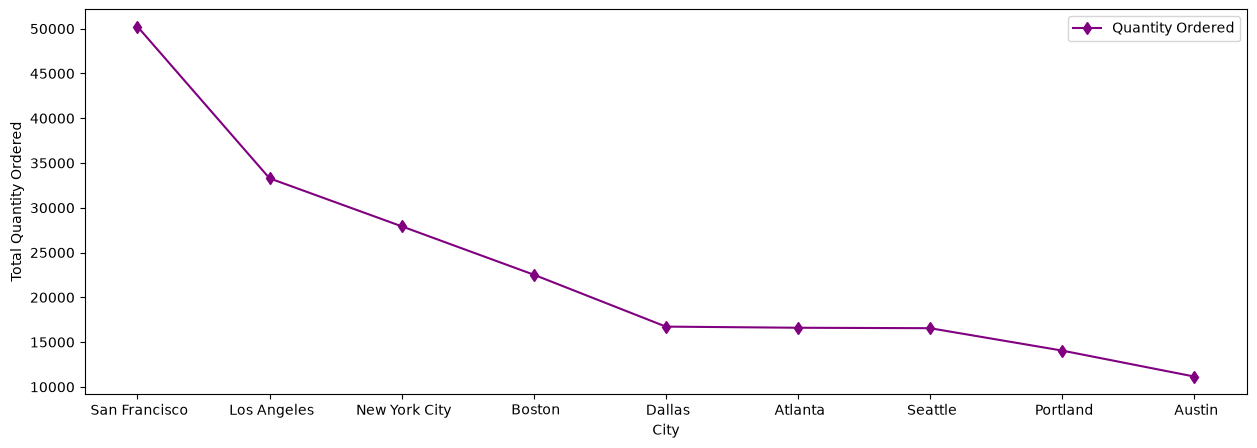

In [42]:
highest_sales.plot(
    kind='line',
    color='purple',
    marker='d',
    figsize=(15,5)
)
plt.legend()
plt.ylabel("Total Quantity Ordered")
plt.show()

- City Sold Most Product: San Francisco

# What time should we display advertisements to maximize the likelihood of customers buying the product?

In [43]:
all_data["Order Date"].head()

0   2019-04-19 08:46:00
1                   NaT
2   2019-04-07 22:30:00
3   2019-04-12 14:38:00
4   2019-04-12 14:38:00
Name: Order Date, dtype: datetime64[us]

In [44]:
all_data['Time'] = all_data["Order Date"].dt.time
all_data['Time']

0         08:46:00
1              NaT
2         22:30:00
3         14:38:00
4         14:38:00
            ...   
186845    20:56:00
186846    16:00:00
186847    07:39:00
186848    17:30:00
186849    00:18:00
Name: Time, Length: 186495, dtype: object

In [45]:
all_data['Hour'] = all_data["Order Date"].dt.hour
all_data['Hour']

0          8.0
1          NaN
2         22.0
3         14.0
4         14.0
          ... 
186845    20.0
186846    16.0
186847     7.0
186848    17.0
186849     0.0
Name: Hour, Length: 186495, dtype: float64

In [46]:
all_data['Minutes'] = all_data["Order Date"].dt.minute
all_data['Minutes']

0         46.0
1          NaN
2         30.0
3         38.0
4         38.0
          ... 
186845    56.0
186846     0.0
186847    39.0
186848    30.0
186849    18.0
Name: Minutes, Length: 186495, dtype: float64

In [47]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,TSV,City,Time,Hour,Minutes
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",April,23.90,Dallas,08:46:00,8.0,46.0
1,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",April,99.99,Boston,22:30:00,22.0,30.0
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,600.00,Los Angeles,14:38:00,14.0,38.0
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,11.99,Los Angeles,14:38:00,14.0,38.0


In [48]:
max_selling_time = all_data.groupby('Hour')['Quantity Ordered'].sum().sort_values(ascending=False)
max_selling_time

Hour
19.0    14470.0
12.0    14202.0
11.0    14005.0
18.0    13802.0
20.0    13768.0
13.0    13685.0
14.0    12362.0
10.0    12308.0
21.0    12244.0
17.0    12229.0
16.0    11662.0
15.0    11391.0
22.0     9899.0
9.0      9816.0
23.0     7065.0
8.0      7002.0
7.0      4556.0
0.0      4428.0
6.0      2810.0
1.0      2619.0
5.0      1493.0
2.0      1398.0
4.0       937.0
3.0       928.0
Name: Quantity Ordered, dtype: float64

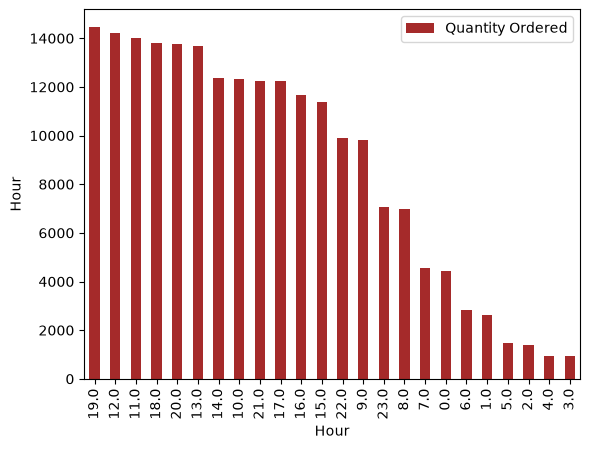

In [49]:
max_selling_time.plot(
    kind='bar',
    color='brown'
)

plt.legend()
plt.ylabel("Hour")
plt.show()

# What Products are most often sold together?

- Same Order ID for different products suggests the customer bought different products together in Our Data. 

- Let us look for Duplicate OrderId Products:

In [58]:
df = all_data['Order ID'].duplicated(keep=False)
df.value_counts()

Order ID
False    171301
True      15194
Name: count, dtype: int64

In [59]:
all_data

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,TSV,City,Time,Hour,Minutes
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",April,23.90,Dallas,08:46:00,8.0,46.0
1,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaT,NaN,NaN
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",April,99.99,Boston,22:30:00,22.0,30.0
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,600.00,Los Angeles,14:38:00,14.0,38.0
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",April,11.99,Los Angeles,14:38:00,14.0,38.0
...,...,...,...,...,...,...,...,...,...,...,...,...
186845,259353,AAA Batteries (4-pack),3.0,2.99,2019-09-17 20:56:00,"840 Highland St, Los Angeles, CA 90001",September,8.97,Los Angeles,20:56:00,20.0,56.0
186846,259354,iPhone,1.0,700.00,2019-09-01 16:00:00,"216 Dogwood St, San Francisco, CA 94016",September,700.00,San Francisco,16:00:00,16.0,0.0
186847,259355,iPhone,1.0,700.00,2019-09-23 07:39:00,"220 12th St, San Francisco, CA 94016",September,700.00,San Francisco,07:39:00,7.0,39.0
186848,259356,34in Ultrawide Monitor,1.0,379.99,2019-09-19 17:30:00,"511 Forest St, San Francisco, CA 94016",September,379.99,San Francisco,17:30:00,17.0,30.0


In [52]:
all_data.to_excel(fr"{base_path}\all_data.xlsx" , index = False)

- Group Different Products With Same Order ID :

- Let's create a new column that contains different Products with the same Order ID. We can do this with the help of the transform method.

In [60]:
df

0         False
1          True
2         False
3          True
4          True
          ...  
186845    False
186846    False
186847    False
186848    False
186849    False
Name: Order ID, Length: 186495, dtype: bool

In [55]:
df['Grouped'] = df.groupby('Order ID')['Product'].transform(lambda x : ','.join(x))
df.head(10)

KeyError: 'Order ID'